# Cross-architecture lock comparison — Apple M3, Graviton, Xeon

Three concurrent indexes were swept on three machines. Each CSV row has a
leading `arch` and `hostname` column populated by `bench_harness::detect_arch`
(see `include/util/bench_harness.hpp`).

| Machine | Arch tag | Hostname | Logical CPUs | Sweeps available |
|---|---|---|---|---|
| Apple M3 Pro | `apple_m3` | Andreis-MacBook-Pro-7 | 11 | wh_compare only |
| AWS Graviton (ARM Linux) | `graviton` | ip-172-31-19-57 | 8 | full |
| Xeon (x86 Linux) | `xeon` | diascld45 | 48 (sudo-less, no `setup_cpu.sh`) | full |

**Workloads** (constant across benches): `uniform 80/10/10`, `uniform 90/5/5`,
`zipfian 80/10/10`, `zipfian 20/40/40`. Per-run: 3 s measure, 1 s warmup,
1 repeat — except Xeon which (without frequency lock) shows ~5–15% more
variance run-to-run.

**What this notebook shows**

1. Per-arch throughput-vs-threads grids (one panel per workload, all locks).
2. Cross-arch overlays at the common thread points 1, 2, 4, 8.
3. Fairness (`min/max` per-thread ops) at each arch's maximum thread count.
4. Scaling-efficiency summary tables.

Wormhole is the only bench that ran on all three machines. StripedMap and
BronsonAVL are Graviton vs Xeon only.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('..').resolve()

WH_LOCKS  = ['default', 'rw', 'tas', 'ttas', 'cas', 'occ', 'occ-opt']
CDS_LOCKS = ['std', 'tas', 'ttas', 'cas', 'ticket']
AVL_LOCKS = CDS_LOCKS

# Match plot_cross_arch.py palettes for visual continuity with the saved PNGs.
WH_PALETTE  = {'default':'#888','rw':'#444','tas':'tab:blue','ttas':'tab:green',
               'cas':'tab:orange','occ':'tab:purple','occ-opt':'tab:red'}
CDS_PALETTE = {'std':'#888','tas':'tab:blue','ttas':'tab:green','cas':'tab:orange','ticket':'tab:red'}
AVL_PALETTE = CDS_PALETTE

# Architecture line styles: solid for Apple, dashed for Graviton, dotted for Xeon.
ARCH_STYLE = {'apple_m3': '-', 'graviton': '--', 'xeon': ':'}
ARCH_MARKER = {'apple_m3': 'o', 'graviton': 's', 'xeon': '^'}
ARCH_ORDER = ['apple_m3', 'graviton', 'xeon']

def workload_tag(row):
    rd, ins = int(row['read_pct']), int(row['insert_pct'])
    if rd == 80 and ins == 10:  return f"{row['dist']} 80/10/10"
    if rd == 90 and ins == 5:   return 'uniform 90/5/5 read-heavy'
    if rd == 20 and ins == 40:  return 'zipfian 20/40/40 write-heavy'
    return f"{row['dist']} {rd}/{ins}/{100-rd-ins}"

def load(glob, prefix):
    """Concatenate every CSV matching `glob`, normalize lock and workload columns."""
    csvs = sorted(ROOT.glob(glob))
    if not csvs:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(c, sep=';', decimal=',') for c in csvs], ignore_index=True)
    df['lk'] = df['lock'].str.replace(prefix, '', regex=False)
    df['workload'] = df.apply(workload_tag, axis=1)
    return df

wh  = load('results/*/wh_compare/wh.csv',         'wh-')
cds = load('results/*/avl_compare/cds_striped.csv','cds-')
avl = load('results/*/avl_compare/cds_avl.csv',   'avl-')

for name, df in [('Wormhole', wh), ('StripedMap', cds), ('BronsonAVL', avl)]:
    print(f"{name:11} rows={len(df):4d}  archs={sorted(df.arch.unique()) if len(df) else []}")

Wormhole    rows= 448  archs=['apple_m3', 'graviton', 'xeon']
StripedMap  rows= 220  archs=['graviton', 'xeon']
BronsonAVL  rows= 220  archs=['graviton', 'xeon']


## Inventory — what's actually in each CSV

In [2]:
def inventory(df, name):
    if df.empty:
        return pd.DataFrame()
    g = df.groupby('arch').agg(
        rows=('lock', 'size'),
        locks=('lk', lambda s: ','.join(sorted(s.unique()))),
        threads=('threads', lambda s: ','.join(map(str, sorted(s.unique())))),
        workloads=('workload', 'nunique'),
    ).reset_index()
    g.insert(0, 'bench', name)
    return g

inv = pd.concat([inventory(wh,'wh'), inventory(cds,'cds'), inventory(avl,'avl')], ignore_index=True)
inv

,bench,arch,rows,locks,threads,workloads
0,wh,apple_m3,140,"cas,default,occ,occ-opt,rw,tas,ttas","1,2,4,8,11",4
1,wh,graviton,112,"cas,default,occ,occ-opt,rw,tas,ttas","1,2,4,8",4
2,wh,xeon,196,"cas,default,occ,occ-opt,rw,tas,ttas","1,2,4,8,16,32,48",4
3,cds,graviton,80,"cas,std,tas,ticket,ttas","1,2,4,8",4
4,cds,xeon,140,"cas,std,tas,ticket,ttas","1,2,4,8,16,32,48",4
5,avl,graviton,80,"cas,std,tas,ticket,ttas","1,2,4,8",4
6,avl,xeon,140,"cas,std,tas,ticket,ttas","1,2,4,8,16,32,48",4


## Wormhole — throughput vs threads, per architecture

One figure per architecture, 2×2 grid of workloads, all 7 lock variants. Uses
the full thread range of each machine (Apple stops at 11, Graviton at 8, Xeon
at 48). Scales differ between archs — this view is for comparing locks
*within* a machine, not across.

`wh-default` is upstream-wormhole's stock `rwlock` (no shim); `wh-rw` is our
`rw_lock` reader-writer; `wh-occ-opt` is the optimistic-reader variant.

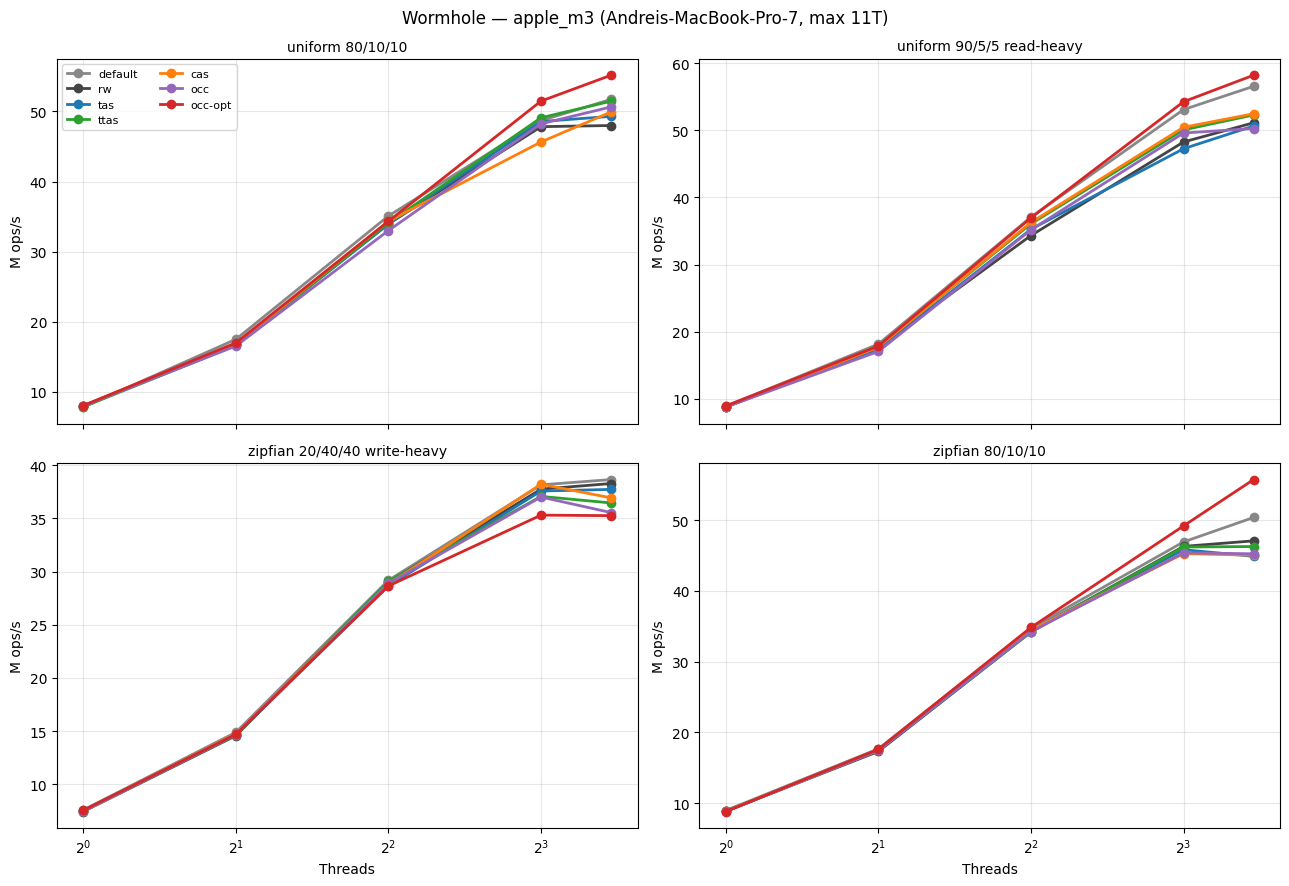

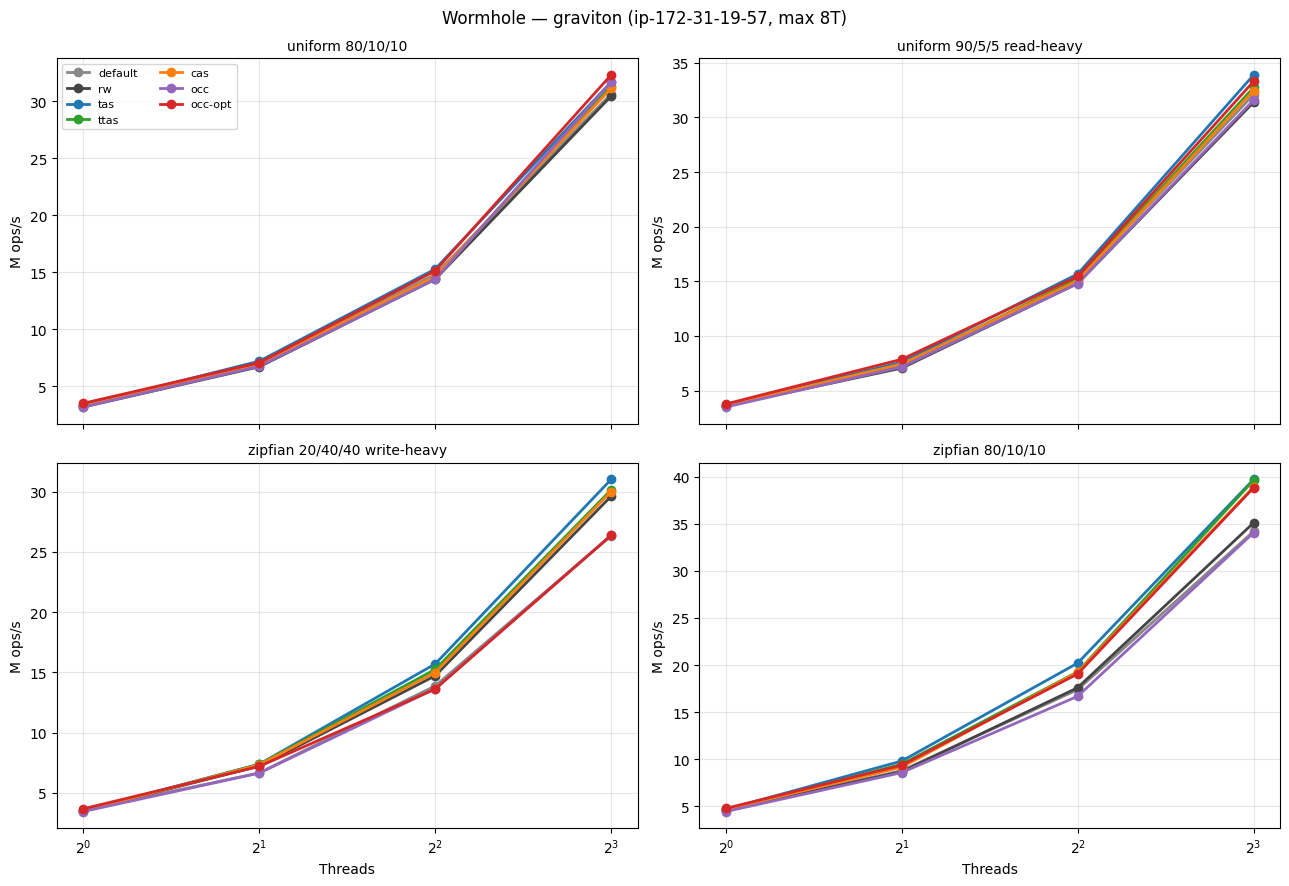

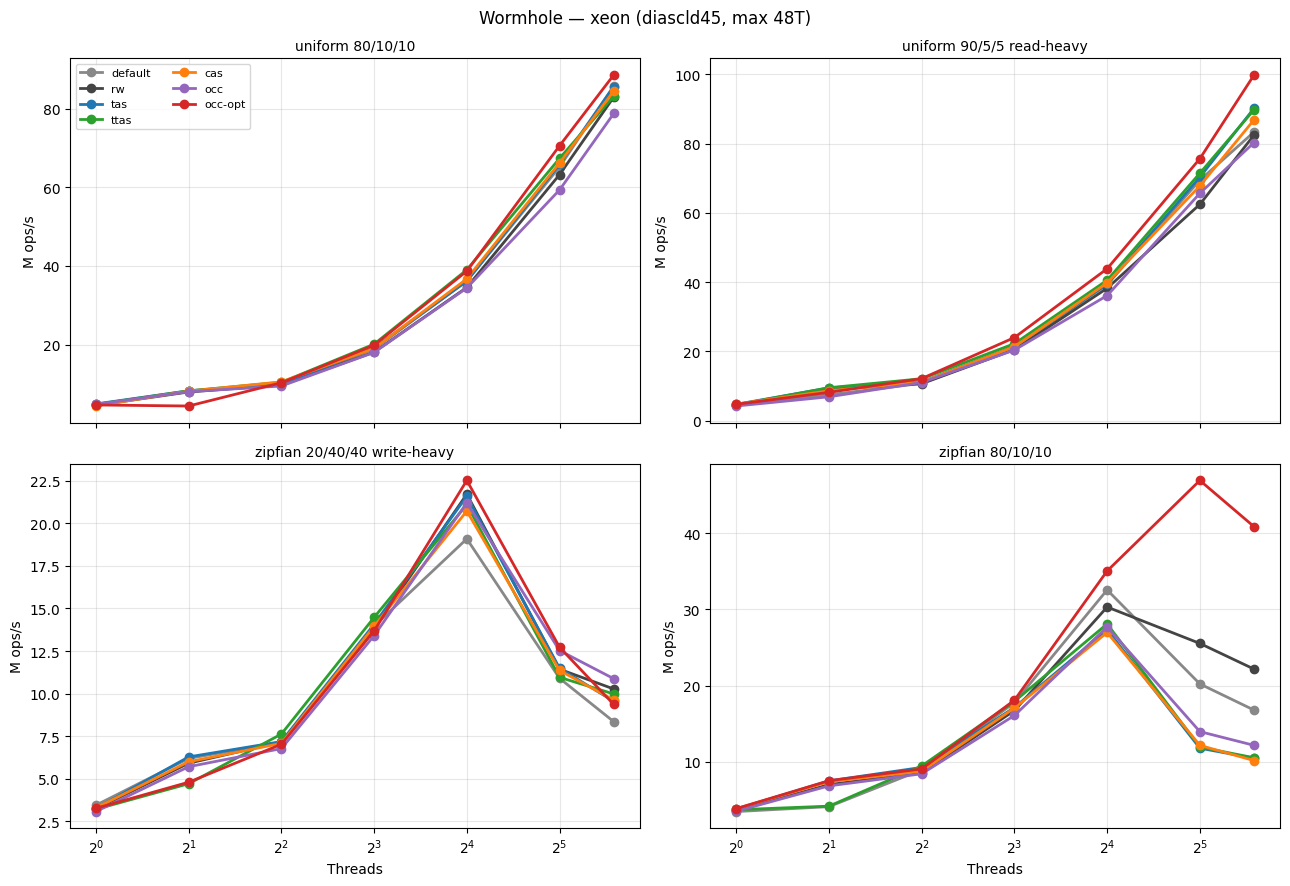

In [3]:
def per_arch_grid(df, locks, palette, title_prefix):
    """One figure per arch; 2x2 of workloads with all locks."""
    workloads = sorted(df.workload.unique())
    archs = [a for a in ARCH_ORDER if a in df.arch.unique()]
    figs = []
    for arch in archs:
        sub = df[df.arch == arch]
        fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
        for ax, wkl in zip(axes.flat, workloads):
            wsub = sub[sub.workload == wkl]
            for lk in locks:
                g = wsub[wsub.lk == lk].sort_values('threads')
                if g.empty: continue
                ax.plot(g.threads, g.ops_s/1e6, marker='o', linewidth=2,
                        color=palette[lk], label=lk)
            ax.set_title(wkl, fontsize=10)
            ax.set_xscale('log', base=2)
            ax.grid(True, alpha=0.3)
            ax.set_ylabel('M ops/s')
        for ax in axes[-1]: ax.set_xlabel('Threads')
        axes[0,0].legend(fontsize=8, ncol=2, loc='best')
        host = sub.hostname.iloc[0]
        max_t = int(sub.threads.max())
        fig.suptitle(f'{title_prefix} — {arch} ({host}, max {max_t}T)', fontsize=12)
        fig.tight_layout()
        figs.append(fig)
    return figs

_ = per_arch_grid(wh, WH_LOCKS, WH_PALETTE, 'Wormhole')
plt.show()

## Wormhole — cross-architecture overlay at common thread points

Apple/Graviton/Xeon all sampled `1, 2, 4, 8` threads, so this is the apples-
to-apples slice. Color = lock; line style = arch (solid Apple, dashed
Graviton, dotted Xeon). One panel per workload.

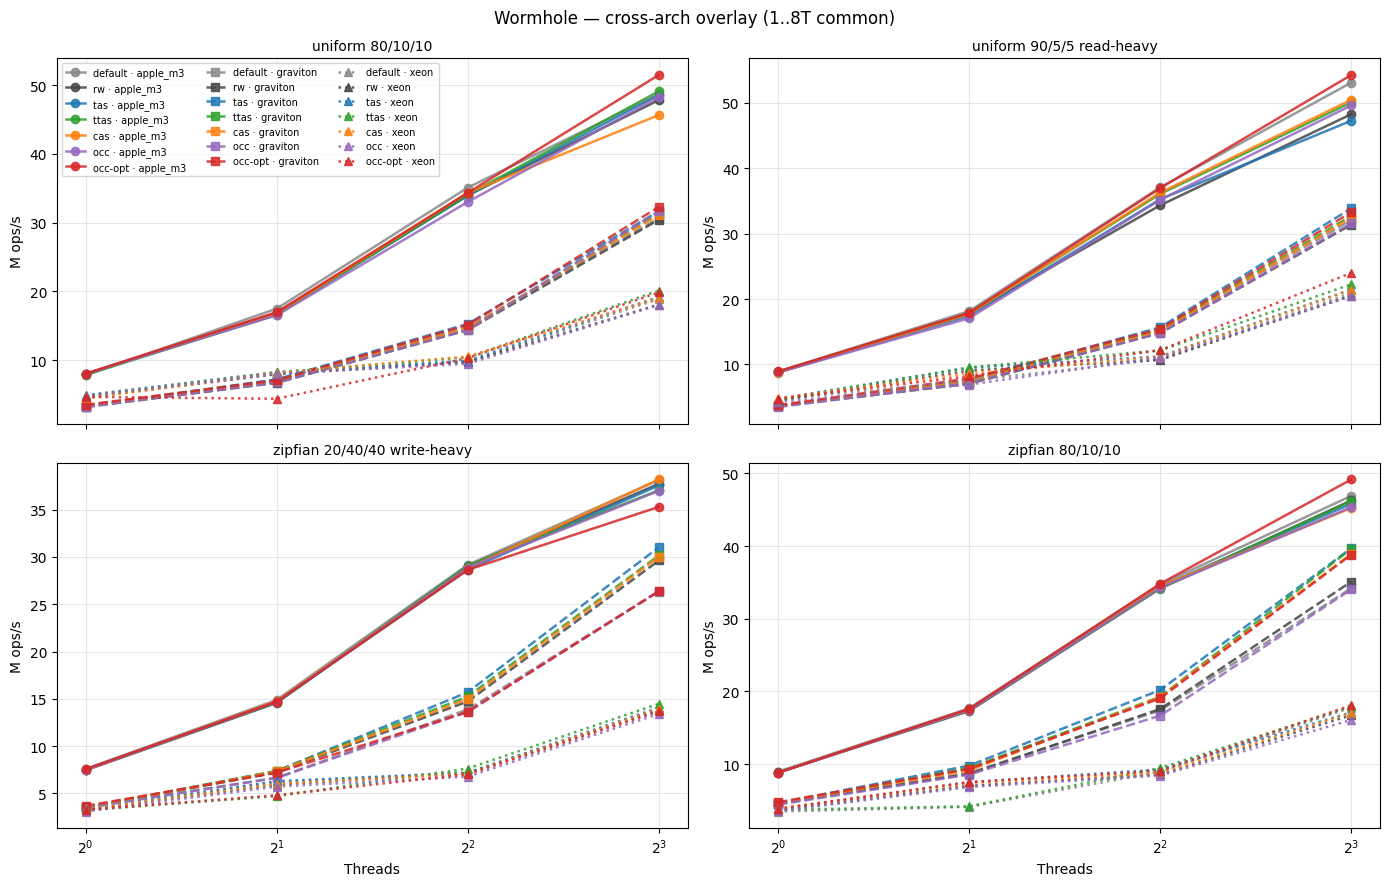

In [4]:
def cross_arch_overlay(df, locks, palette, title_prefix, max_threads=8):
    workloads = sorted(df.workload.unique())
    archs = [a for a in ARCH_ORDER if a in df.arch.unique()]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    for ax, wkl in zip(axes.flat, workloads):
        wsub = df[(df.workload == wkl) & (df.threads <= max_threads)]
        for arch in archs:
            for lk in locks:
                g = wsub[(wsub.arch == arch) & (wsub.lk == lk)].sort_values('threads')
                if g.empty: continue
                ax.plot(g.threads, g.ops_s/1e6, color=palette[lk],
                        linestyle=ARCH_STYLE[arch], marker=ARCH_MARKER[arch],
                        linewidth=1.8, alpha=0.85, label=f'{lk} · {arch}')
        ax.set_title(wkl, fontsize=10)
        ax.set_xscale('log', base=2)
        ax.grid(True, alpha=0.3)
        ax.set_ylabel('M ops/s')
    for ax in axes[-1]: ax.set_xlabel('Threads')
    axes[0,0].legend(fontsize=7, ncol=3, loc='best')
    fig.suptitle(f'{title_prefix} — cross-arch overlay (1..{max_threads}T common)', fontsize=12)
    fig.tight_layout()
    return fig

_ = cross_arch_overlay(wh, WH_LOCKS, WH_PALETTE, 'Wormhole')
plt.show()

## Wormhole — fairness at each arch's maximum thread count

`fairness_ratio = min(per-thread ops) / max(per-thread ops)` per run. 1.0 is
perfect parity; lower means some threads got more cycles than others. We
look at this at *max* threads per arch — fairness almost always matters most
under contention.

Bar groups: one cluster per lock. Bar color/alpha encodes the architecture.

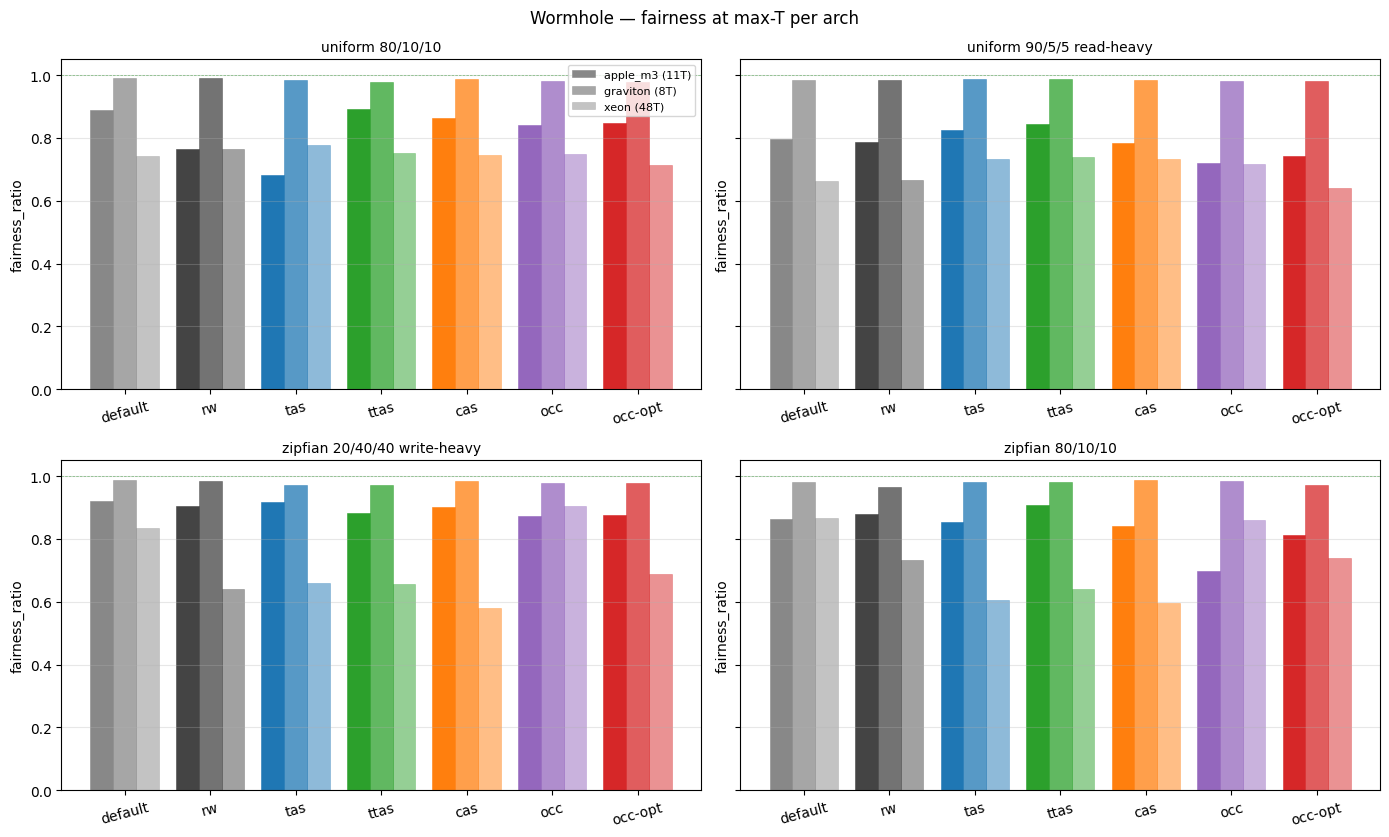

In [5]:
def fairness_at_maxT(df, locks, palette, title_prefix):
    workloads = sorted(df.workload.unique())
    archs = [a for a in ARCH_ORDER if a in df.arch.unique()]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharey=True)
    width = 0.8 / max(1, len(archs))
    x = np.arange(len(locks))
    for ax, wkl in zip(axes.flat, workloads):
        sub = df[df.workload == wkl]
        for ai, arch in enumerate(archs):
            asub = sub[sub.arch == arch]
            if asub.empty: continue
            max_t = int(asub.threads.max())
            ys = []
            for lk in locks:
                g = asub[(asub.lk == lk) & (asub.threads == max_t)]
                ys.append(float(g.fairness_ratio.mean()) if len(g) else 0.0)
            offset = (ai - (len(archs)-1)/2) * width
            bars = ax.bar(x + offset, ys, width=width,
                          edgecolor='black', linewidth=0.4,
                          label=f'{arch} ({max_t}T)')
            for bar, lk in zip(bars, locks):
                bar.set_color(palette[lk])
                bar.set_alpha(1.0 - 0.25 * ai)
        ax.set_title(wkl, fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(locks, rotation=15)
        ax.axhline(1.0, color='green', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_ylim(0, 1.05)
        ax.grid(True, axis='y', alpha=0.3)
        ax.set_ylabel('fairness_ratio')
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'{title_prefix} — fairness at max-T per arch', fontsize=12)
    fig.tight_layout()
    return fig

_ = fairness_at_maxT(wh, WH_LOCKS, WH_PALETTE, 'Wormhole')
plt.show()

## libcds StripedMap — Graviton vs Xeon

(No Apple data for cdsbench / avl_compare — only the wh sweep was run on
the laptop.)

StripedMap distributes work across N=64 stripes; contention is the
per-stripe lock. Five lock primitives: `std`, `tas`, `ttas`, `cas`, `ticket`.

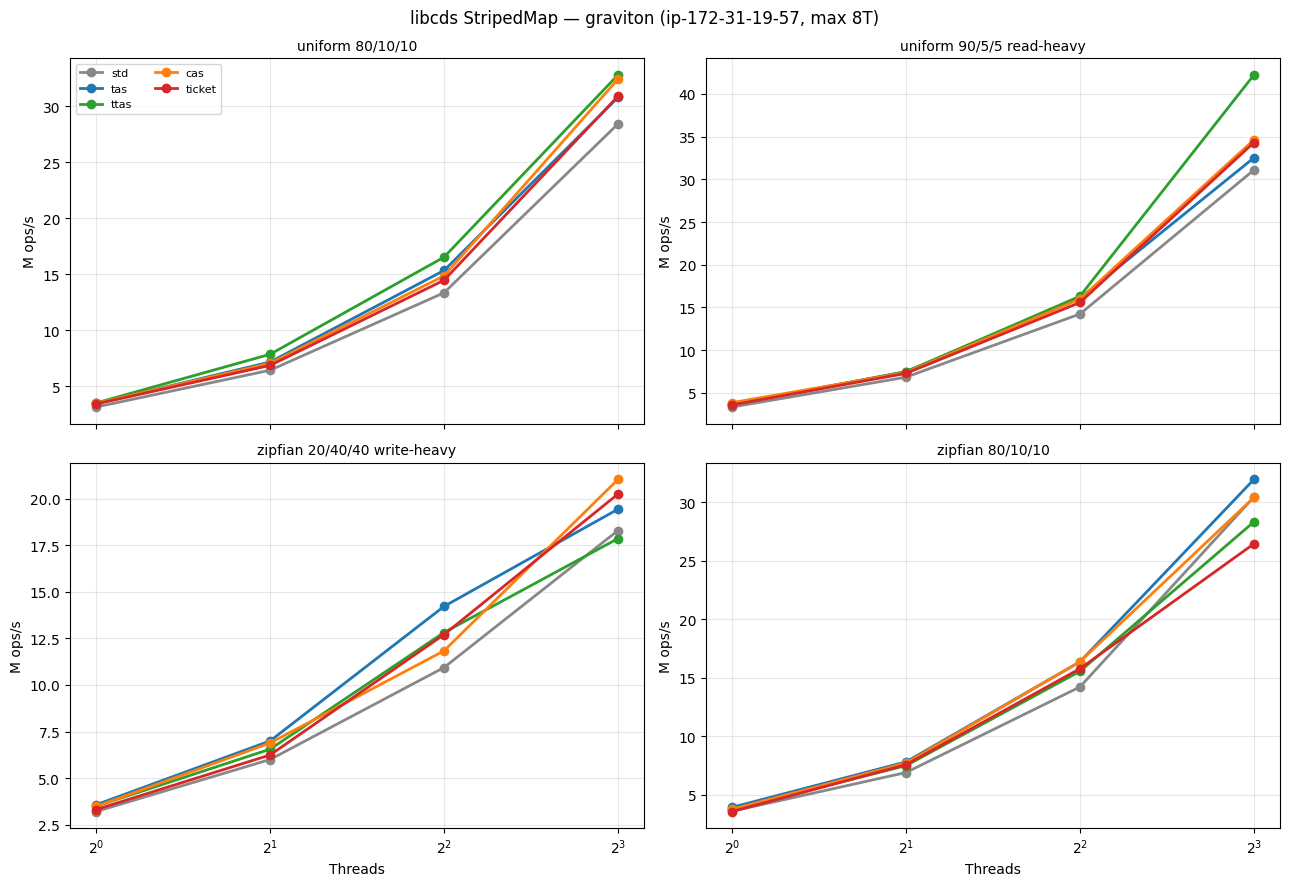

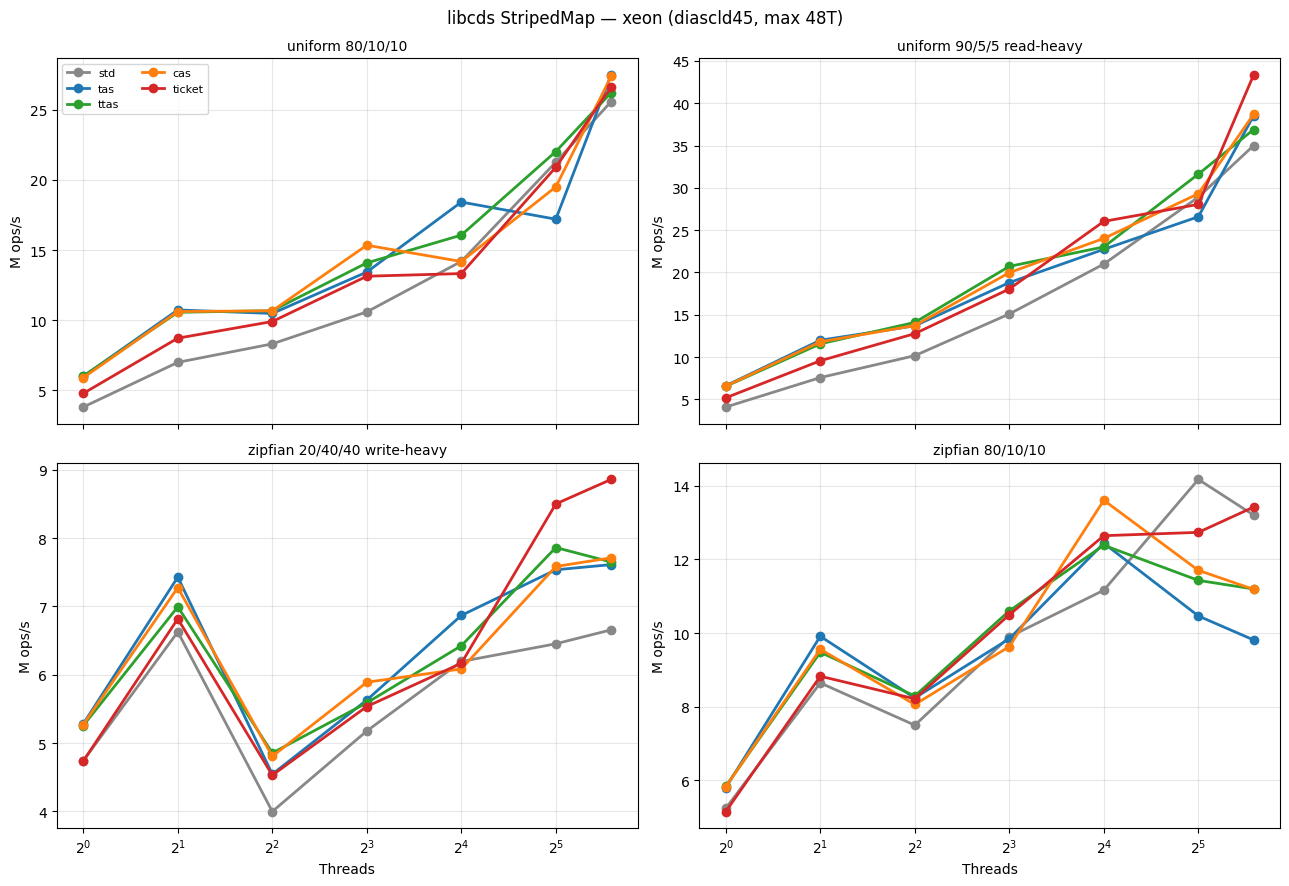

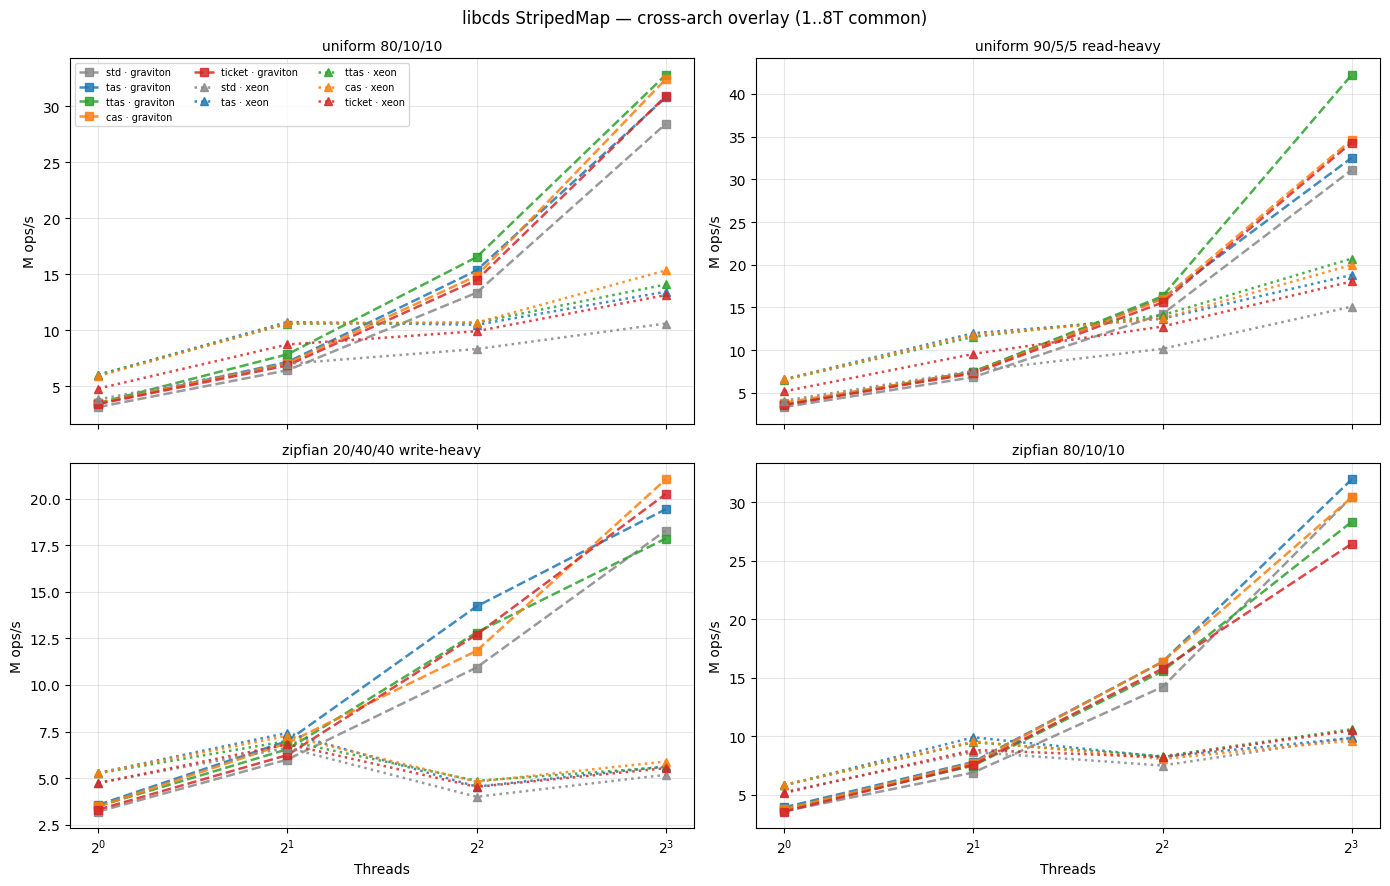

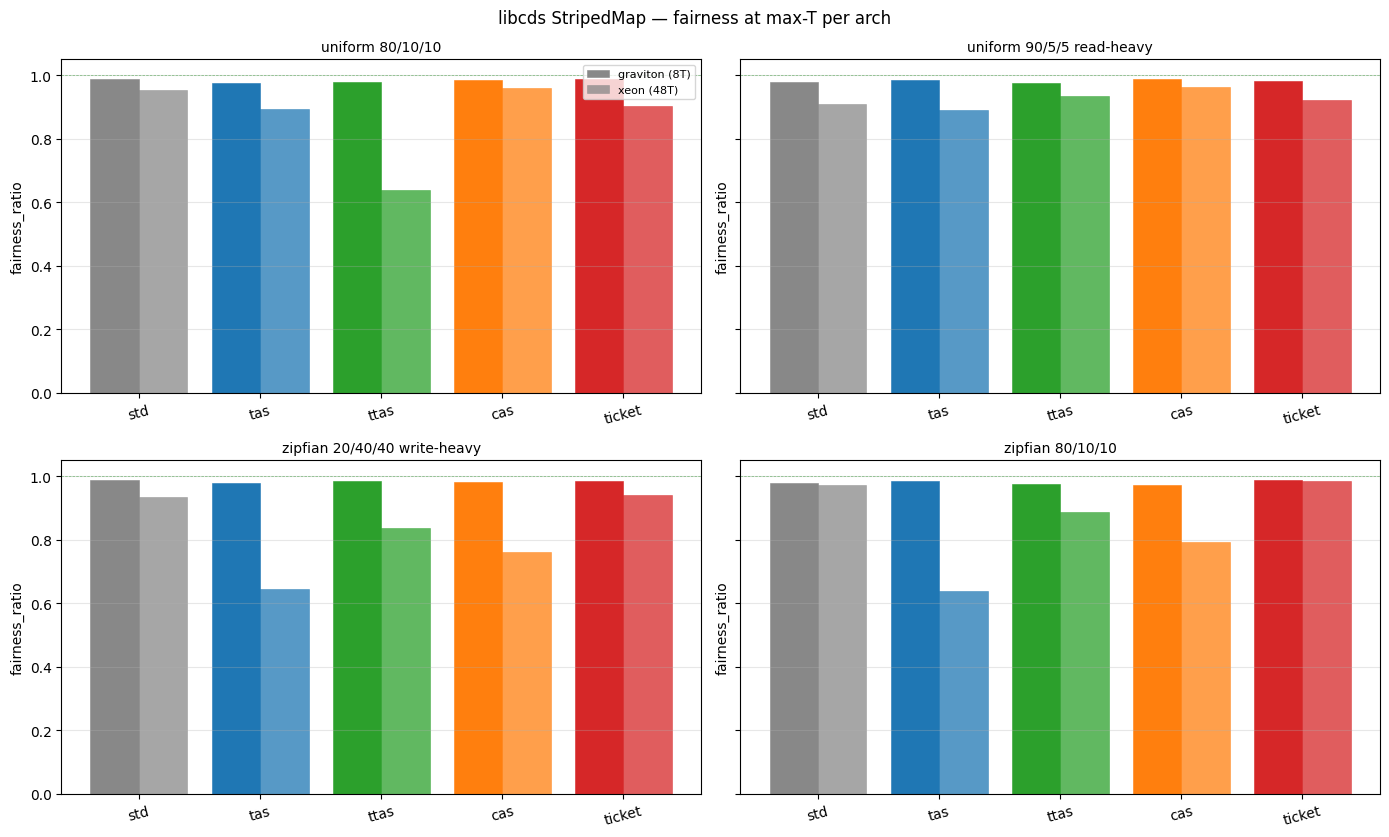

In [6]:
_ = per_arch_grid(cds, CDS_LOCKS, CDS_PALETTE, 'libcds StripedMap')
plt.show()

_ = cross_arch_overlay(cds, CDS_LOCKS, CDS_PALETTE, 'libcds StripedMap')
plt.show()

_ = fairness_at_maxT(cds, CDS_LOCKS, CDS_PALETTE, 'libcds StripedMap')
plt.show()

## libcds BronsonAVLTreeMap — Graviton vs Xeon

BronsonAVL has per-node monitor locks; contention surface is much smaller
than StripedMap (only the modified path), so write-heavy workloads behave
differently.

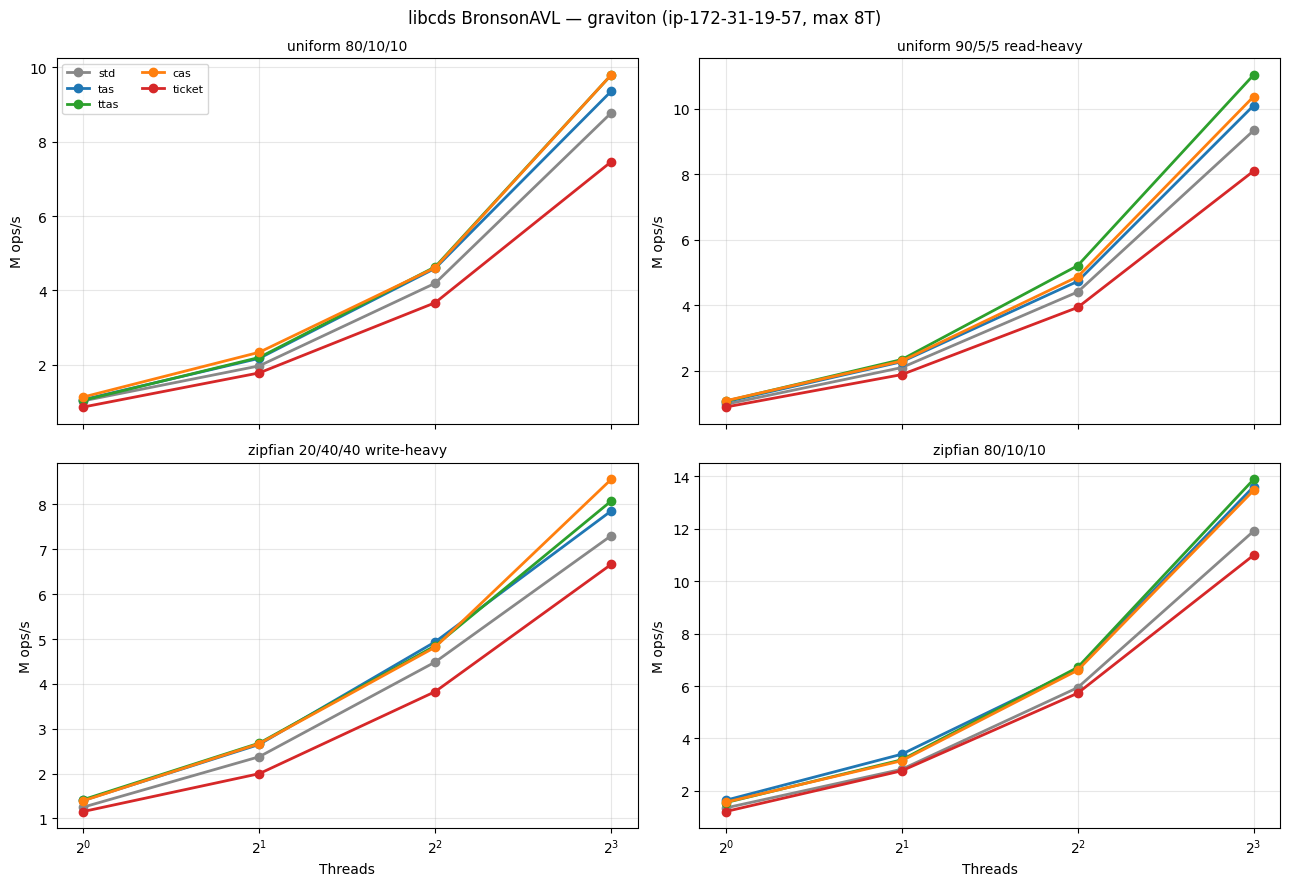

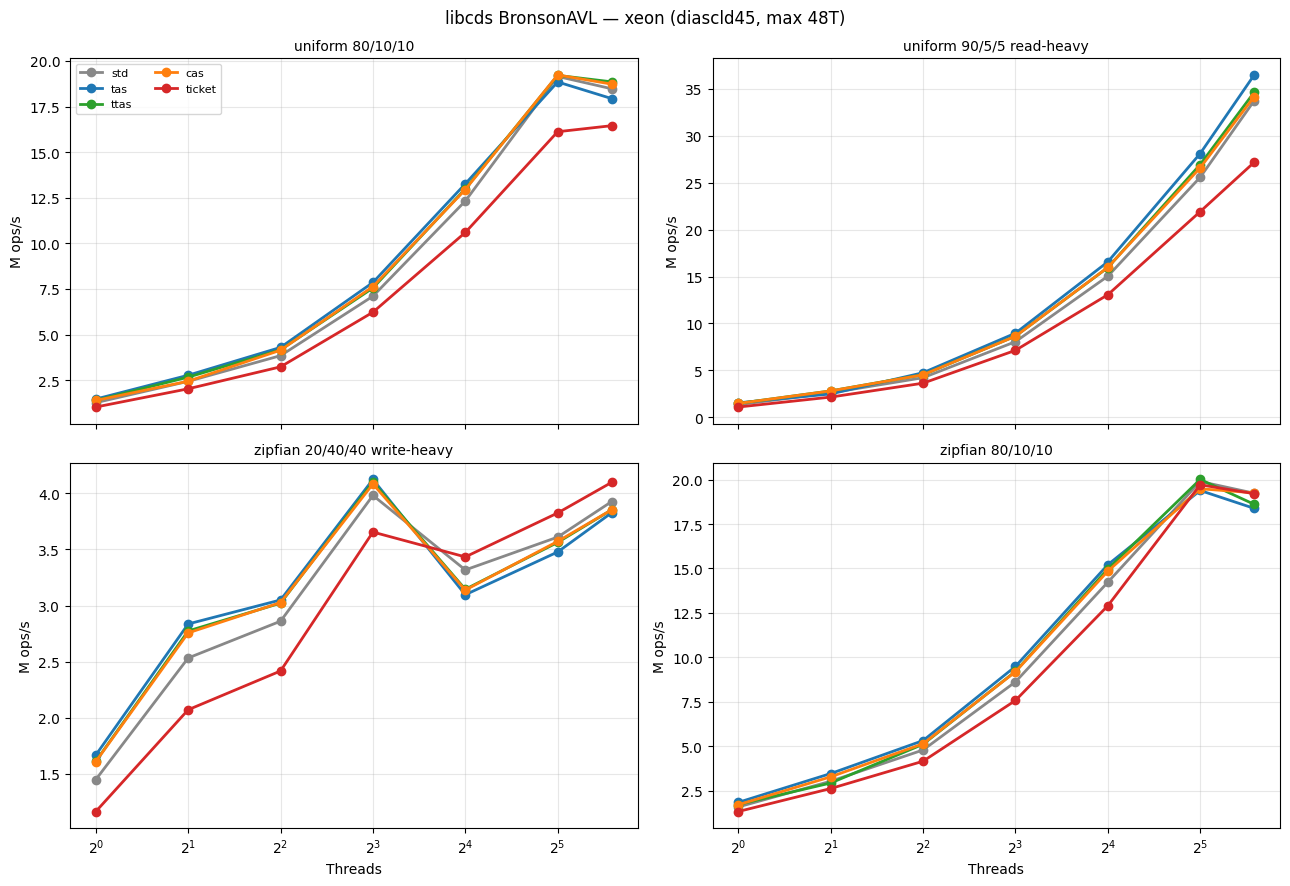

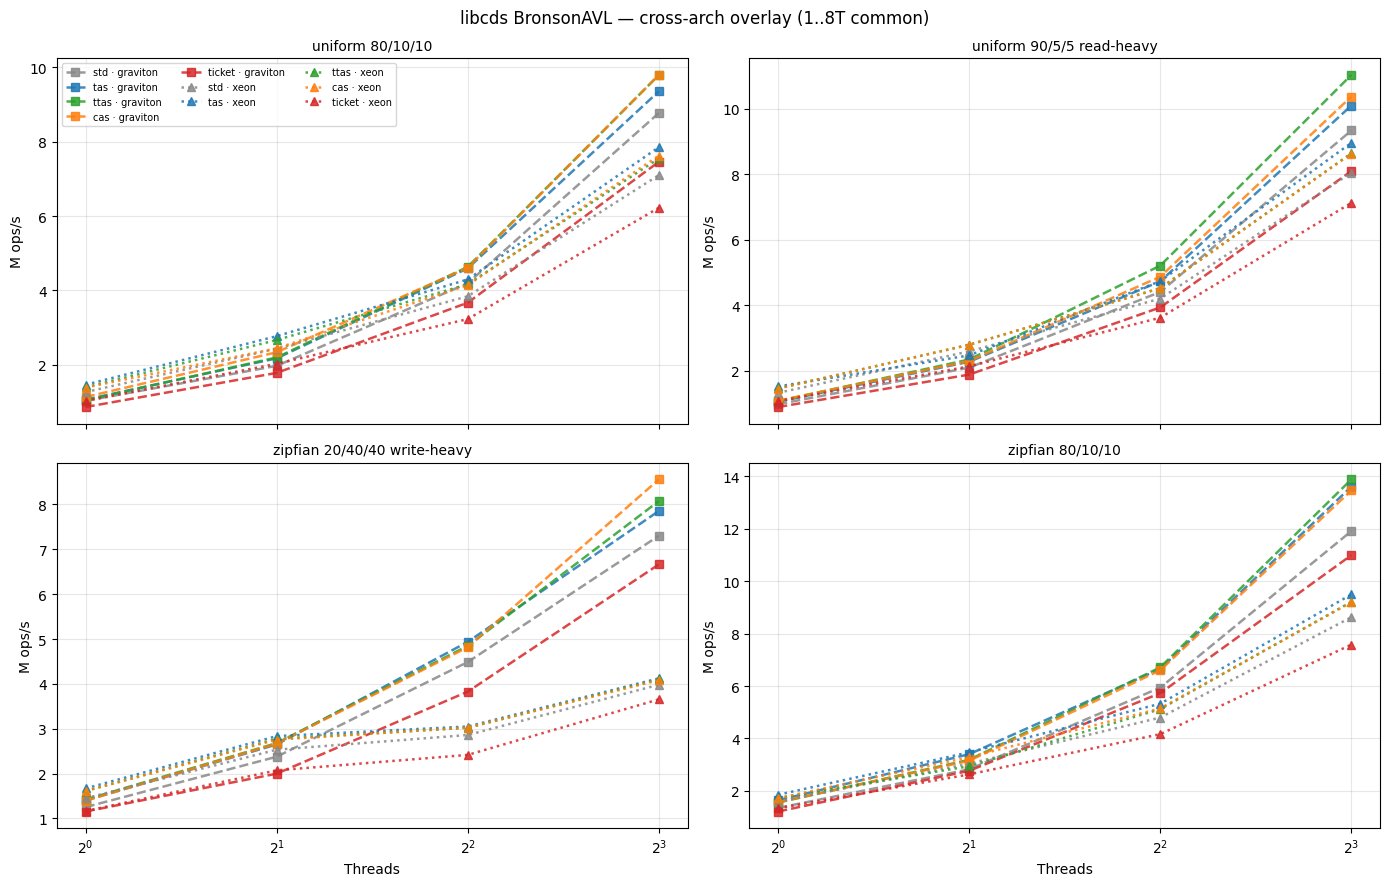

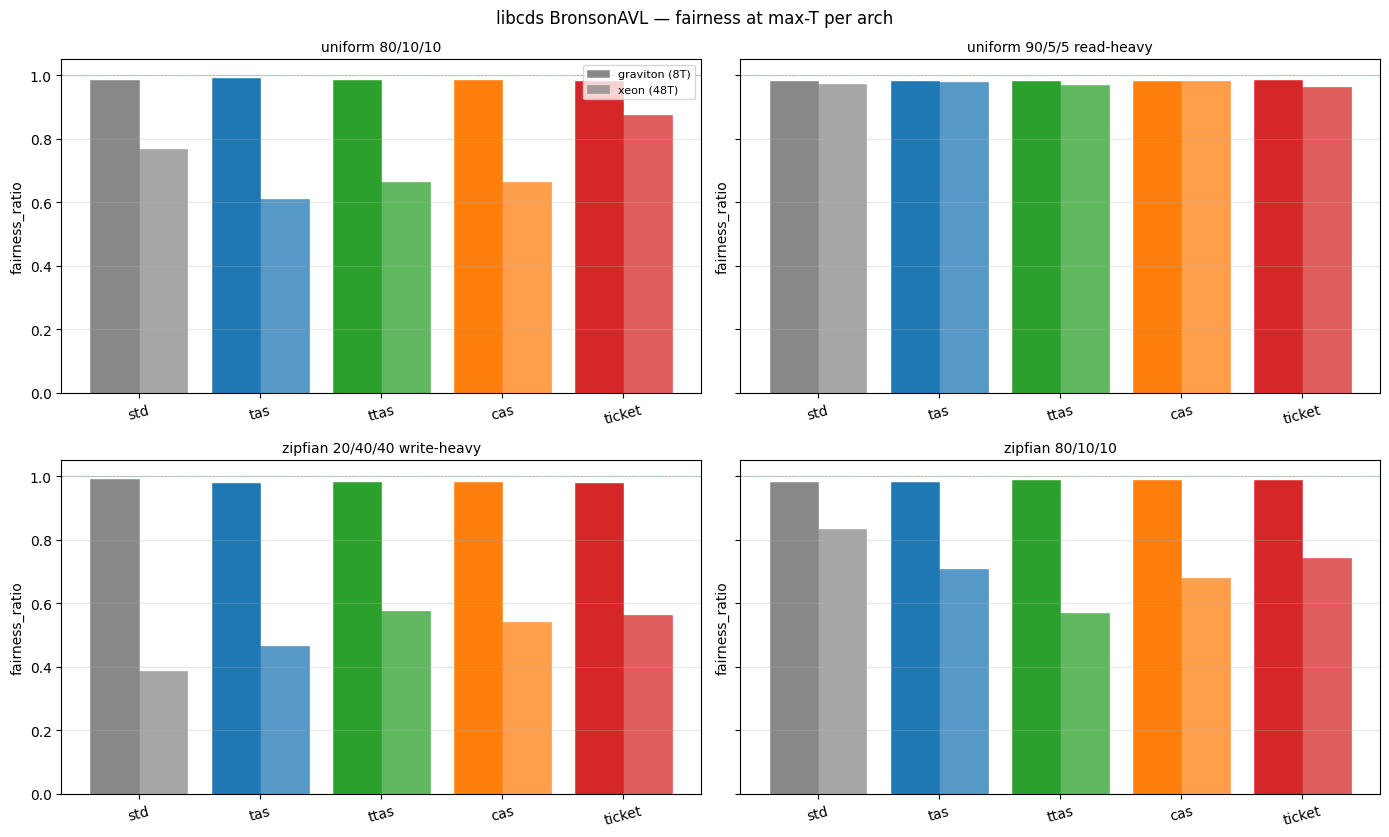

In [7]:
_ = per_arch_grid(avl, AVL_LOCKS, AVL_PALETTE, 'libcds BronsonAVL')
plt.show()

_ = cross_arch_overlay(avl, AVL_LOCKS, AVL_PALETTE, 'libcds BronsonAVL')
plt.show()

_ = fairness_at_maxT(avl, AVL_LOCKS, AVL_PALETTE, 'libcds BronsonAVL')
plt.show()

## Scaling efficiency at max threads

`efficiency = ops_s(maxT) / (maxT × ops_s(1T))` — 1.0 means linear scaling,
0.5 means half of perfect parallel speedup. Computed per arch since `maxT`
differs (Apple 11, Graviton 8, Xeon 48). Useful for ranking locks within
an arch — comparing absolute efficiency *across* archs is unfair because
Xeon is being asked to scale to 48T while Graviton stops at 8T.

In [8]:
def scaling_table(df, locks):
    rows = []
    for arch in [a for a in ARCH_ORDER if a in df.arch.unique()]:
        for wkl in sorted(df.workload.unique()):
            sub = df[(df.arch == arch) & (df.workload == wkl)]
            if sub.empty: continue
            max_t = int(sub.threads.max())
            for lk in locks:
                g1 = sub[(sub.lk == lk) & (sub.threads == 1)]
                gm = sub[(sub.lk == lk) & (sub.threads == max_t)]
                if g1.empty or gm.empty: continue
                base = float(g1.ops_s.iloc[0]); peak = float(gm.ops_s.iloc[0])
                rows.append({
                    'arch': arch, 'workload': wkl, 'lock': lk,
                    'max_T': max_t,
                    'ops_s_1T_M':   round(base / 1e6, 2),
                    'ops_s_maxT_M': round(peak / 1e6, 2),
                    'speedup':      round(peak / base, 2),
                    'efficiency':   round(peak / (base * max_t), 3),
                    'fairness':     round(float(gm.fairness_ratio.iloc[0]), 3),
                })
    return pd.DataFrame(rows)

wh_scale = scaling_table(wh, WH_LOCKS)
wh_scale

,arch,workload,lock,max_T,ops_s_1T_M,ops_s_maxT_M,speedup,efficiency,fairness
0,apple_m3,uniform 80/10/10,default,11,7.81,51.72,6.63,0.602,0.890
1,apple_m3,uniform 80/10/10,rw,11,7.97,47.99,6.02,0.548,0.763
2,apple_m3,uniform 80/10/10,tas,11,7.99,49.30,6.17,0.561,0.681
3,apple_m3,uniform 80/10/10,ttas,11,7.85,51.46,6.55,0.596,0.891
4,apple_m3,uniform 80/10/10,cas,11,8.02,49.93,6.23,0.566,0.864
...,...,...,...,...,...,...,...,...,...
79,xeon,zipfian 80/10/10,tas,48,3.81,10.48,2.75,0.057,0.604
80,xeon,zipfian 80/10/10,ttas,48,3.73,10.55,2.83,0.059,0.641
81,xeon,zipfian 80/10/10,cas,48,3.87,10.18,2.63,0.055,0.598
82,xeon,zipfian 80/10/10,occ,48,3.54,12.18,3.44,0.072,0.859


In [9]:
cds_scale = scaling_table(cds, CDS_LOCKS)
cds_scale

,arch,workload,lock,max_T,ops_s_1T_M,ops_s_maxT_M,speedup,efficiency,fairness
0,graviton,uniform 80/10/10,std,8,3.13,28.43,9.08,1.135,0.988
1,graviton,uniform 80/10/10,tas,8,3.45,30.81,8.93,1.116,0.975
2,graviton,uniform 80/10/10,ttas,8,3.49,32.81,9.39,1.174,0.980
3,graviton,uniform 80/10/10,cas,8,3.46,32.44,9.37,1.171,0.986
4,graviton,uniform 80/10/10,ticket,8,3.40,30.91,9.08,1.135,0.988
5,graviton,uniform 90/5/5 read-heavy,std,8,3.35,31.09,9.27,1.159,0.979
6,graviton,uniform 90/5/5 read-heavy,tas,8,3.66,32.51,8.89,1.111,0.985
7,graviton,uniform 90/5/5 read-heavy,ttas,8,3.65,42.21,11.55,1.444,0.975
8,graviton,uniform 90/5/5 read-heavy,cas,8,3.87,34.62,8.95,1.119,0.988
9,graviton,uniform 90/5/5 read-heavy,ticket,8,3.60,34.30,9.53,1.191,0.982


In [10]:
avl_scale = scaling_table(avl, AVL_LOCKS)
avl_scale

,arch,workload,lock,max_T,ops_s_1T_M,ops_s_maxT_M,speedup,efficiency,fairness
0,graviton,uniform 80/10/10,std,8,1.03,8.78,8.51,1.063,0.985
1,graviton,uniform 80/10/10,tas,8,1.06,9.36,8.79,1.099,0.990
2,graviton,uniform 80/10/10,ttas,8,1.05,9.80,9.36,1.170,0.985
3,graviton,uniform 80/10/10,cas,8,1.13,9.80,8.64,1.080,0.984
4,graviton,uniform 80/10/10,ticket,8,0.87,7.46,8.63,1.078,0.983
5,graviton,uniform 90/5/5 read-heavy,std,8,0.99,9.33,9.47,1.184,0.983
6,graviton,uniform 90/5/5 read-heavy,tas,8,1.06,10.09,9.52,1.189,0.981
7,graviton,uniform 90/5/5 read-heavy,ttas,8,1.08,11.03,10.20,1.275,0.983
8,graviton,uniform 90/5/5 read-heavy,cas,8,1.09,10.37,9.49,1.186,0.983
9,graviton,uniform 90/5/5 read-heavy,ticket,8,0.90,8.10,8.99,1.123,0.986


## Best lock per (arch × workload)

Highest `ops_s` at max-T — quick way to spot which primitive to default
to on each machine for each workload mix.

In [11]:
def winners(scale_df, name):
    if scale_df.empty:
        return pd.DataFrame()
    idx = scale_df.groupby(['arch', 'workload'])['ops_s_maxT_M'].idxmax()
    w = scale_df.loc[idx, ['arch','workload','lock','ops_s_maxT_M','efficiency','fairness']].reset_index(drop=True)
    w.insert(0, 'bench', name)
    return w

pd.concat([winners(wh_scale,'wh'), winners(cds_scale,'cds'), winners(avl_scale,'avl')],
          ignore_index=True)

,bench,arch,workload,lock,ops_s_maxT_M,efficiency,fairness
0,wh,apple_m3,uniform 80/10/10,occ-opt,55.17,0.624,0.847
1,wh,apple_m3,uniform 90/5/5 read-heavy,occ-opt,58.22,0.591,0.741
2,wh,apple_m3,zipfian 20/40/40 write-heavy,default,38.65,0.463,0.920
3,wh,apple_m3,zipfian 80/10/10,occ-opt,55.71,0.574,0.811
4,wh,graviton,uniform 80/10/10,occ-opt,32.29,1.150,0.979
5,wh,graviton,uniform 90/5/5 read-heavy,tas,33.89,1.162,0.988
6,wh,graviton,zipfian 20/40/40 write-heavy,tas,31.03,1.107,0.971
7,wh,graviton,zipfian 80/10/10,tas,39.72,1.066,0.980
8,wh,xeon,uniform 80/10/10,occ-opt,88.57,0.396,0.714
9,wh,xeon,uniform 90/5/5 read-heavy,occ-opt,99.80,0.436,0.641


## Notes for interpretation

- **Apple's 11T point** crosses the P-/E-core boundary on M3 Pro (6 P-cores,
  5 E-cores). The dip from 8T → 11T isn't a lock pathology, it's the OS
  scheduler placing the extra threads on slower E-cores. Compare locks at
  Apple's 8T point for fairness.
- **Xeon ran without `setup_cpu.sh`** (no sudo on `diascld45`). DVFS and
  turbo are active, so per-run variance is higher than Apple/Graviton.
  Lock *ranking* is still meaningful; absolute ops/s less so.
- **Graviton stops at 8T** — that's the c6g instance's full core count,
  no SMT. Cross-arch comparisons use 1..8T because that's the common range.
- **`wh-occ-opt`** validates with a per-leaf seqlock counter; readers don't
  take the leaflock at all. Expect the biggest gap vs `wh-occ` on read-heavy
  workloads (`90/5/5`, zipfian `80/10/10`).
- **Ticket lock excluded from Wormhole** — its try-lock approximation
  (empty-queue CAS) interacts poorly with wormhole's reader fast path.
  See `docs/EXPERIMENT.md`.